In [1]:
import pandas as pd 
import numpy as np 
import os 
 

In [2]:
df = pd.read_csv("minor.csv")

In [3]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler 


In [4]:
print(df.info())
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [5]:
#  handelling misssing value 
categorical_cols = df.select_dtypes(include=['str']).columns 
numerical_cols  = df.select_dtypes(include =["float64"]).columns
from sklearn.impute import SimpleImputer
num_imp =  SimpleImputer(strategy= "mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])



cat_imp  = SimpleImputer(strategy ='most_frequent')
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols ]) 




Text(0.5, 1.0, 'is Loan approved or not ?')

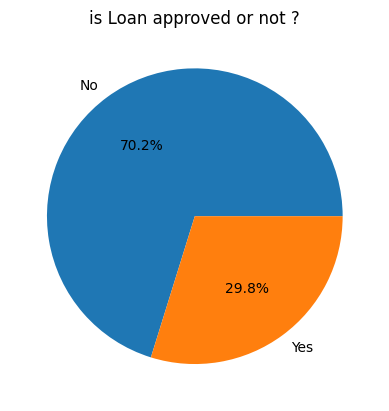

In [6]:
# eda 
# exelporatory data analysis 
# check the  how our classes are balance 
classes_count = df["Loan_Approved"].value_counts()
import matplotlib.pyplot as plt
plt.pie(classes_count,labels=["No","Yes"] , autopct= "%1.1f%%")
plt.title("is Loan approved or not ?")

[Text(0, 0, '621'), Text(0, 0, '379')]

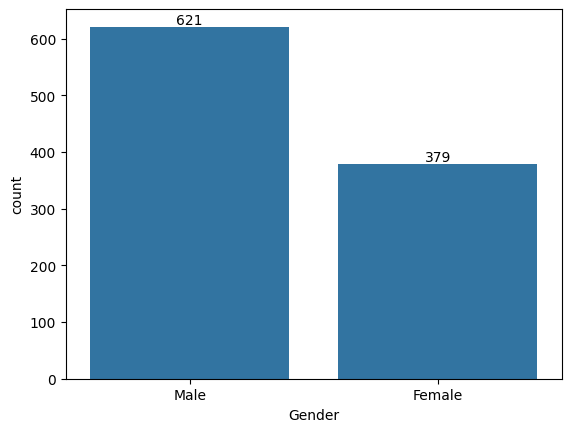

In [7]:
# analyze the category value
import seaborn as sns
gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])




<Axes: xlabel='Applicant_Income', ylabel='Count'>

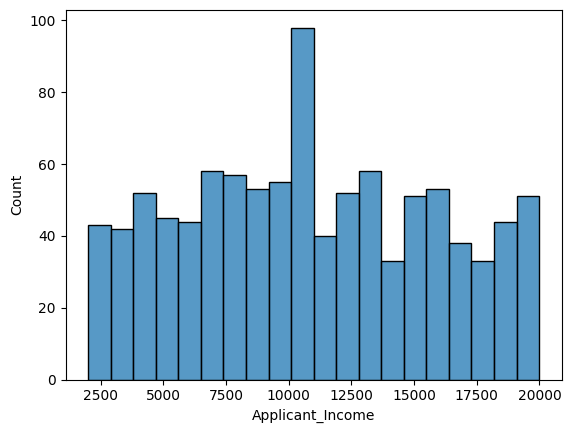

In [8]:
#  income analyze 

sns.histplot(
    data=df,
    x = "Applicant_Income",
    bins= 20
)


<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

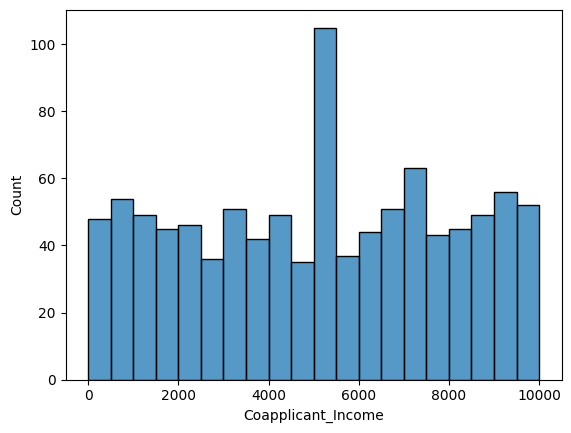

In [9]:
sns.histplot(
    data=df,
    x = "Coapplicant_Income",
    bins= 20
)


<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

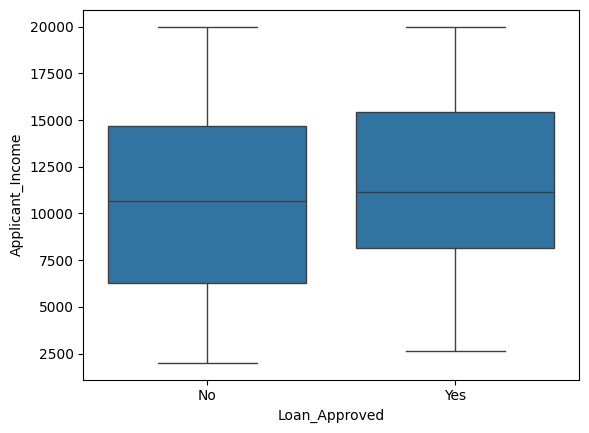

In [10]:
# outliers - box plot


sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y =  "Applicant_Income"
)

<Axes: xlabel='Loan_Approved', ylabel='Credit_Score'>

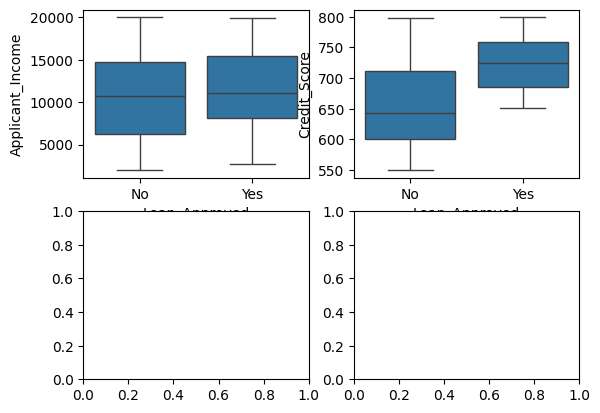

In [11]:
fig,axes = plt.subplots(2,2)
sns.boxplot(ax= axes[0,0], data=df, x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax= axes[0,1], data=df, x="Loan_Approved",y="Credit_Score")
# sns.boxplot(ax= axes[1,0], data=df, x="Loan_Approved",y="DII_Ratio")
# sns.boxplot(ax= axes[1,1], data=df, x="Loan_Approved",y="Saving")

<Axes: xlabel='Credit_Score', ylabel='Count'>

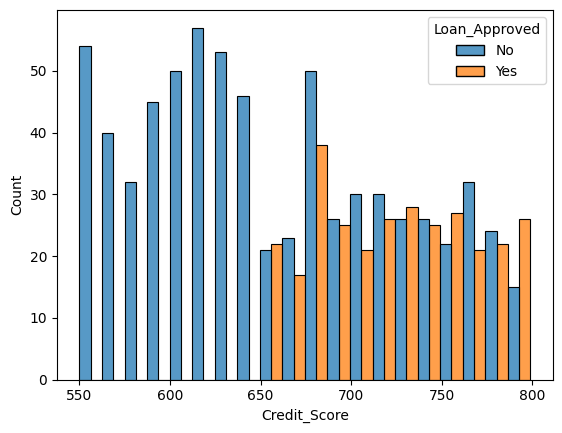

In [12]:
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins= 20 ,
    multiple ="dodge"   
)

In [13]:
df = df.drop(["Applicant_ID"], axis= 1)
df.head()



,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [14]:
# encoding 
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   str    
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   str    
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   str    
 14  Property_Area       1000 non-null   str    
 15  Education_Level     1000 non-null   str    
 16  Gender            

In [15]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df['Education_Level'])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

cols =["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe = OneHotEncoder(
    drop='first',
    sparse_output = False,
    handle_unknown = "ignore"
)

encoded = ohe.fit_transform(df[cols])
ohe.get_feature_names_out(cols)
encoded_df  = pd.DataFrame( encoded, columns =ohe.get_feature_names_out(cols),index =df.index)

In [19]:

df  = pd.concat([df.drop(columns= cols),encoded_df ], axis =1 )


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved                   

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


In [ ]:
moodel.train 